In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
corpus = '''
Artificial intelligence is transforming modern industries and changing the way people work.
Machine learning allows computers to learn patterns from data without being explicitly programmed.
Deep learning is a powerful subset of machine learning that uses neural networks with multiple layers.
Natural language processing helps machines understand human language and generate meaningful responses.
Text generation models can learn grammar, context, and sentence structure from large text corpora.
Students use recurrent neural networks, LSTM networks, and GRU networks to solve sequence prediction problems.
'''
print(corpus)


Artificial intelligence is transforming modern industries and changing the way people work.
Machine learning allows computers to learn patterns from data without being explicitly programmed.
Deep learning is a powerful subset of machine learning that uses neural networks with multiple layers.
Natural language processing helps machines understand human language and generate meaningful responses.
Text generation models can learn grammar, context, and sentence structure from large text corpora.
Students use recurrent neural networks, LSTM networks, and GRU networks to solve sequence prediction problems.



In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split('\n'):
    
    token_list = tokenizer.texts_to_sequences([line])[0]
    
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("Max Sequence Length:", max_len)

Vocabulary Size: 67
X Shape: (76, 15)
y Shape: (76,)
Max Sequence Length: 16


In [4]:
rnn_model = Sequential([
    
    Embedding(total_words,
              64,
              input_length=max_len-1),

    SimpleRNN(128),

    Dense(total_words,
          activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.0000e+00 - loss: 4.2260
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1316 - loss: 4.1024
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2105 - loss: 4.0190 
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2500 - loss: 3.9224
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1974 - loss: 3.8250 
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1974 - loss: 3.7232 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2500 - loss: 3.6030 
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3026 - loss: 3.4758 
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3553 - loss: 3.3456 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3947 - loss: 3.2051 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4079 - loss: 3.0673 
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy:

In [5]:
lstm_model = Sequential([
    
    Embedding(total_words,
              64,
              input_length=max_len-1),

    LSTM(128),

    Dense(total_words,
          activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.0000e+00 - loss: 4.2068
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0921 - loss: 4.1959 
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.1053 - loss: 4.1867
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0658 - loss: 4.1765 
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0658 - loss: 4.1627 
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0921 - loss: 4.1419 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1053 - loss: 4.0982 
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1053 - loss: 4.0371 
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0921 - loss: 3.9705 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0921 - loss: 3.9294 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0789 - loss: 3.8553 
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accurac

In [6]:
gru_model = Sequential([
    
    Embedding(total_words,
              64,
              input_length=max_len-1),

    GRU(128),

    Dense(total_words,
          activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.0000e+00 - loss: 4.2059
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1053 - loss: 4.1914 
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1447 - loss: 4.1791 
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1447 - loss: 4.1666 
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1447 - loss: 4.1535 
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1447 - loss: 4.1381 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1447 - loss: 4.1207 
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1447 - loss: 4.0982 
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1316 - loss: 4.0698 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0921 - loss: 4.0301 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0921 - loss: 3.9677 
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accura

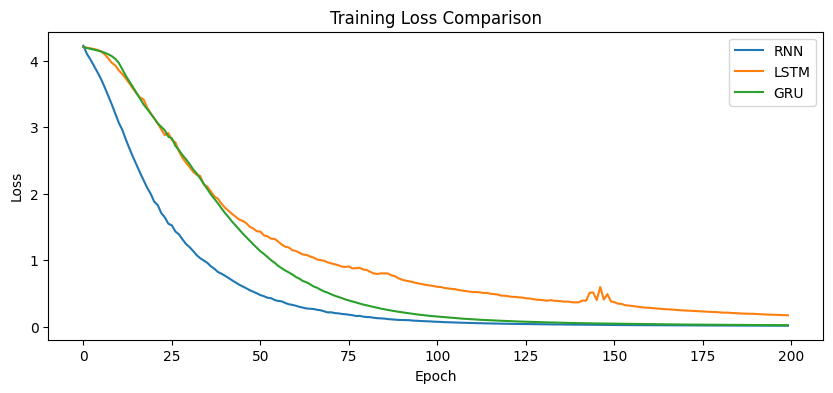

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [8]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text